<a href="https://colab.research.google.com/github/prakash323/ACO/blob/main/FDA_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set Seaborn style for better visualization aesthetics
sns.set(style="whitegrid")

In [ ]:
# Load the dataset
file_path = "/content/Thyroid_Diff.csv"
df = pd.read_csv(file_path)

In [ ]:
# Preview the first few rows
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [ ]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

In [ ]:
# Checking the data types of each column
df.dtypes

,0
Age,int64
Gender,object
Smoking,object
Hx Smoking,object
Hx Radiothreapy,object
Thyroid Function,object
Physical Examination,object
Adenopathy,object
Pathology,object
Focality,object


In [ ]:
# Displaying the first few and last few rows to understand the data visually
df.head()
df.tail()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


Data Cleaning

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Handle missing values if any (example: fill with median, mean, or drop rows)
# Example if filling missing values for a specific column:
# df['column_name'].fillna(df['column_name'].median(), inplace=True)

Missing values in each column:
 Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


Data Transformation

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Label encoding for categorical columns (replace with column names)
categorical_columns = df.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save the encoder for future use

In [ ]:
# One-hot encoding for categorical columns if necessary
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standard scaling for numerical features
numerical_columns = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Min-max normalization
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

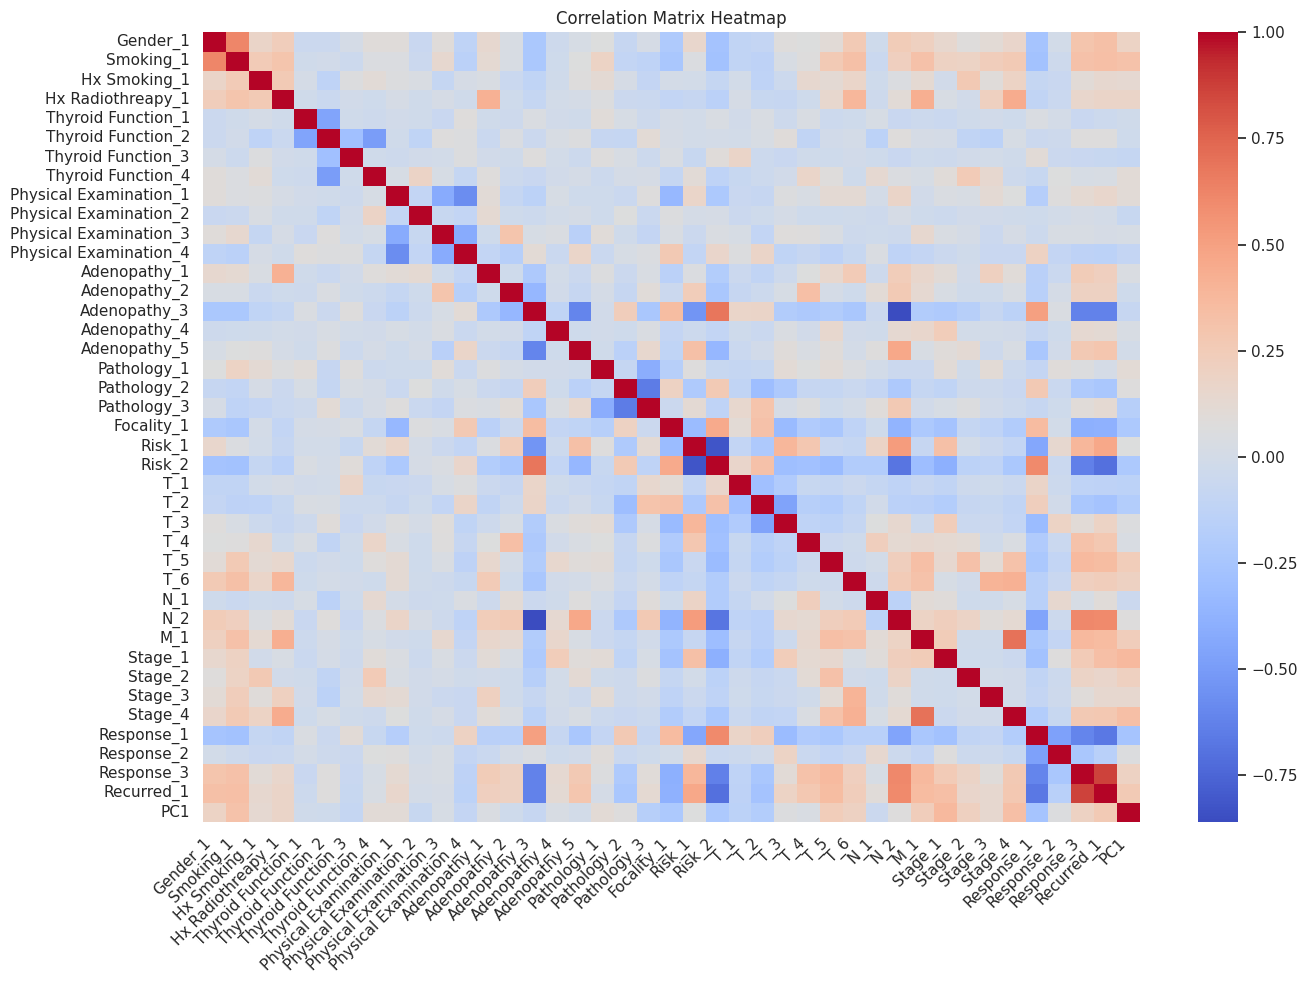

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(14, 10))  # Increase figure size
sns.heatmap(correlation_matrix, cmap="coolwarm", cbar=True)  # Remove annot=True
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()  # Adjust layout to fit everything
plt.show()

Data Reduction

In [ ]:
# Using correlation for feature selection (example)
correlation_matrix = df.corr()
# Selecting features with high correlation with target variable (replace 'target_column' with actual target column)
target_column = 'Risk_1'  # Replace with actual target column name
correlated_features = correlation_matrix[target_column].abs().sort_values(ascending=False)
print("Features correlated with the target:\n", correlated_features)

Features correlated with the target:
 Risk_1                    1.000000
Risk_2                    0.821286
Adenopathy_3              0.538265
N_2                       0.526667
Recurred_1                0.462566
Response_1                0.443404
T_3                       0.387524
Response_3                0.385329
Stage_1                   0.330390
Adenopathy_5              0.324992
Focality_1                0.318216
T_4                       0.287516
Adenopathy_2              0.242995
T_2                       0.220151
Pathology_2               0.210218
N_1                       0.181276
Physical Examination_1    0.168224
Gender_1                  0.153387
Response_2                0.141315
Pathology_3               0.116755
Stage_4                   0.103603
Thyroid Function_4        0.102972
T_1                       0.102001
Physical Examination_4    0.101613
T_6                       0.087999
Hx Radiothreapy_1         0.082206
M_1                       0.077974
Pathology_1      

In [ ]:
from sklearn.decomposition import PCA

# Perform PCA to reduce dimensions while retaining 95% variance
pca = PCA(n_components=0.95)  # Retain 95% of the variance
pca_result = pca.fit_transform(df[numerical_columns])

# Convert PCA result back to a DataFrame for easier handling
df_pca = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])])

# Optional: Add PCA columns back to the main DataFrame (or replace original columns)
df = pd.concat([df.drop(columns=numerical_columns), df_pca], axis=1)

Univariate Analysis

In [ ]:
# Get summary statistics for numerical columns
df.describe()

,PC1
count,3.830000e+02
mean,-9.276015e-18
std,2.258880e-01
min,-3.860722e-01
25%,-1.771170e-01
50%,-5.771404e-02
75%,1.512412e-01
max,6.139278e-01


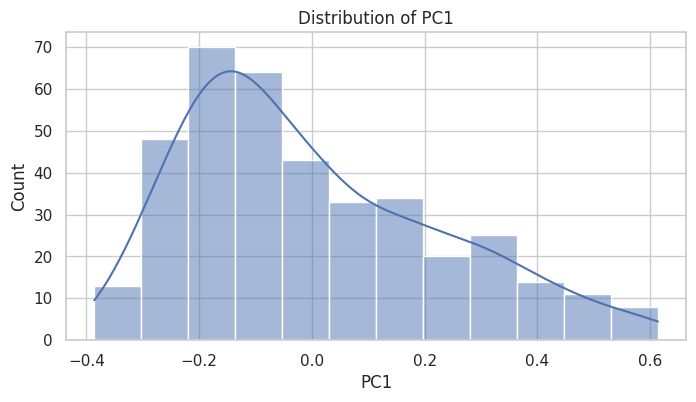

In [ ]:
# Plotting histograms for numerical variables
for col in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


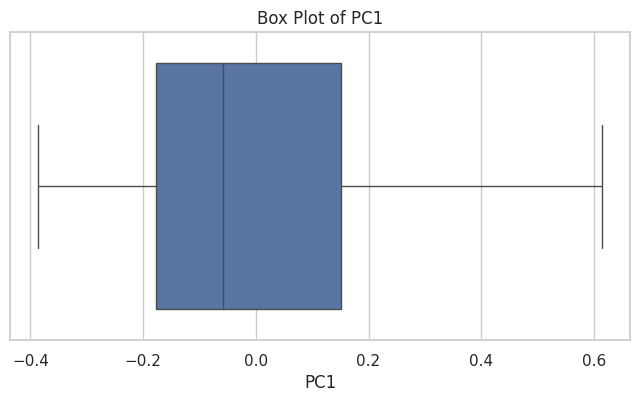

In [ ]:
# Box plots for numerical columns to check for outliers
for col in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

In [ ]:
# Display value counts for categorical columns
for col in df.select_dtypes(include=['object']).columns:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for Gender:
Gender
F    312
M     71
Name: count, dtype: int64


Value counts for Smoking:
Smoking
No     334
Yes     49
Name: count, dtype: int64


Value counts for Hx Smoking:
Hx Smoking
No     355
Yes     28
Name: count, dtype: int64


Value counts for Hx Radiothreapy:
Hx Radiothreapy
No     376
Yes      7
Name: count, dtype: int64


Value counts for Thyroid Function:
Thyroid Function
Euthyroid                      332
Clinical Hyperthyroidism        20
Subclinical Hypothyroidism      14
Clinical Hypothyroidism         12
Subclinical Hyperthyroidism      5
Name: count, dtype: int64


Value counts for Physical Examination:
Physical Examination
Multinodular goiter            140
Single nodular goiter-right    140
Single nodular goiter-left      89
Normal                           7
Diffuse goiter                   7
Name: count, dtype: int64


Value counts for Adenopathy:
Adenopathy
No           277
Right         48
Bilateral     32
Left          17
Extensive      7
Poste

Bivariate Analysis

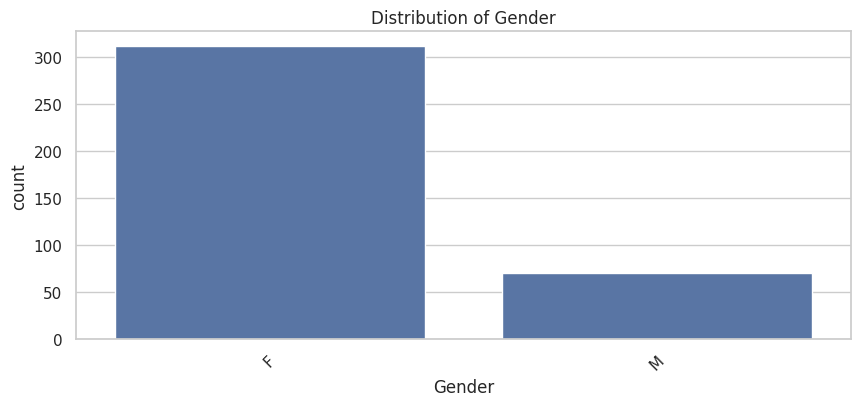

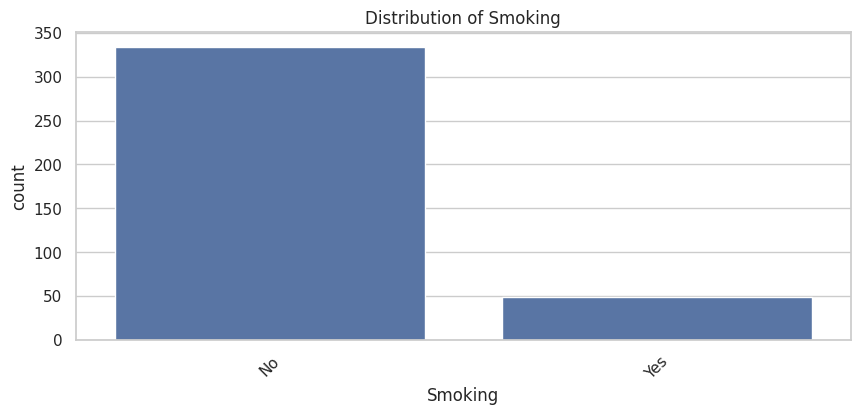

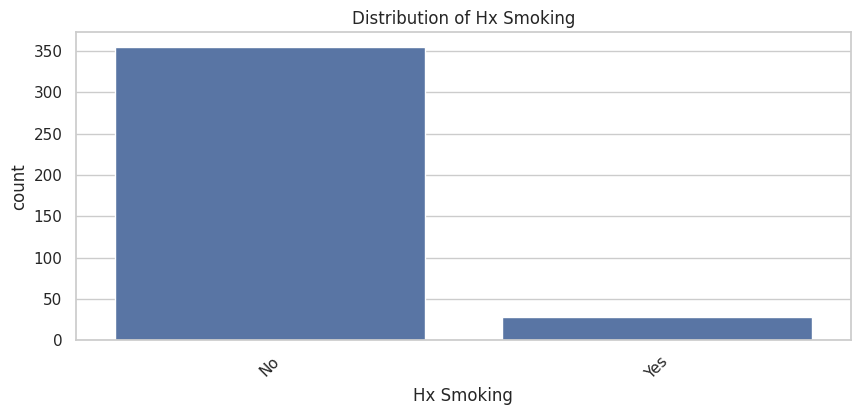

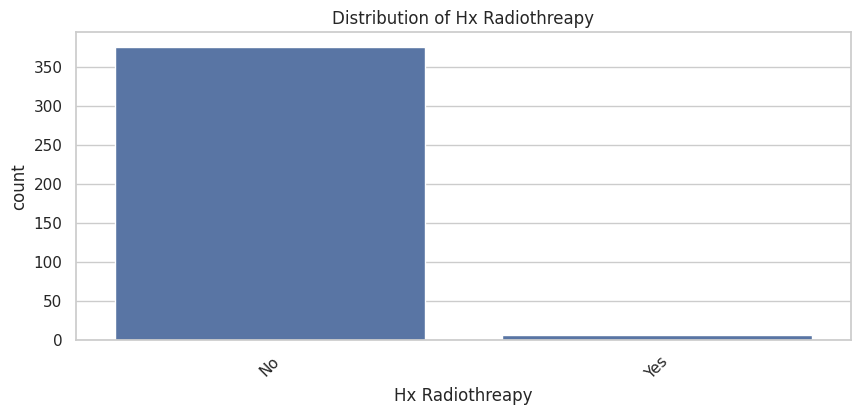

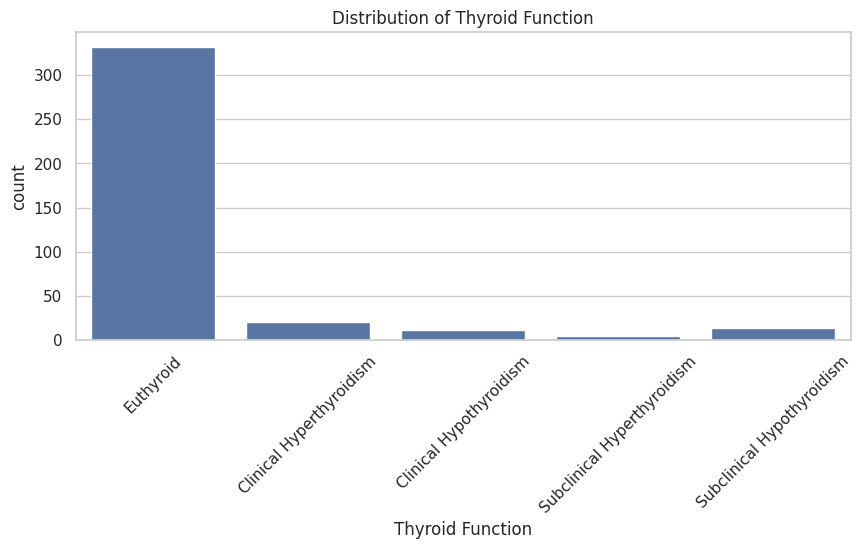

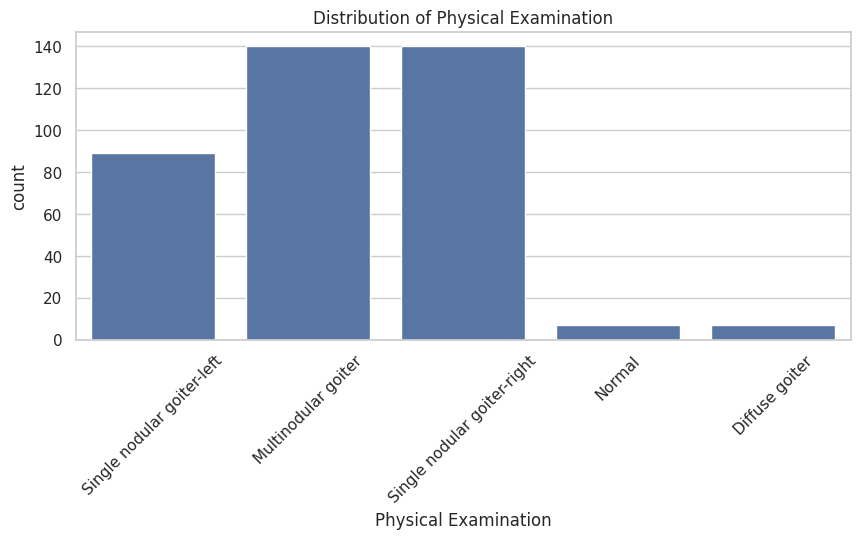

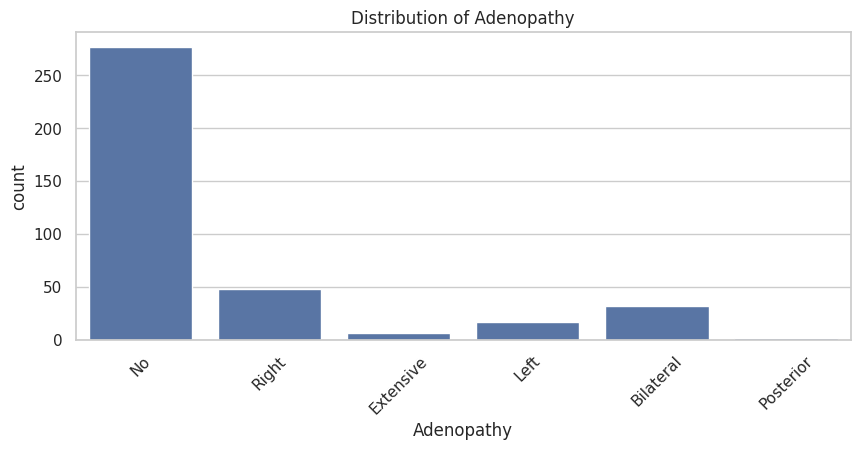

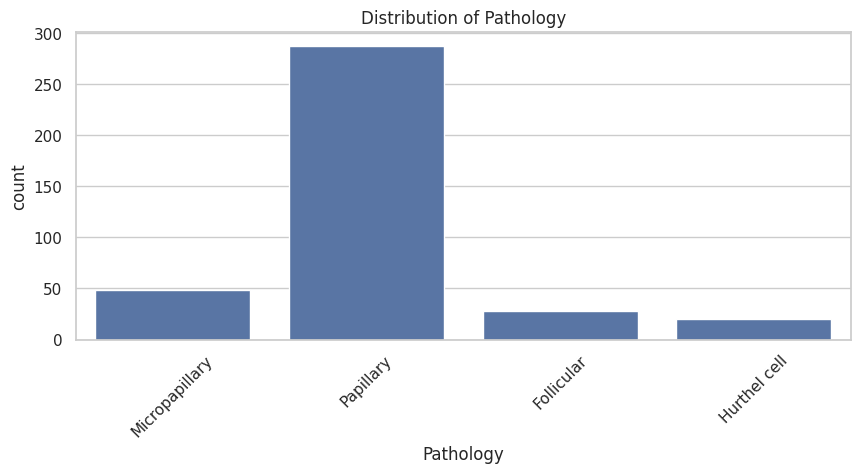

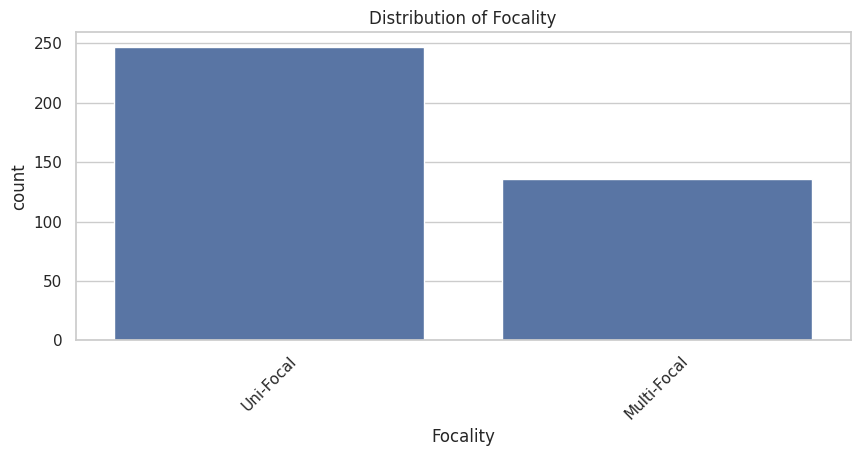

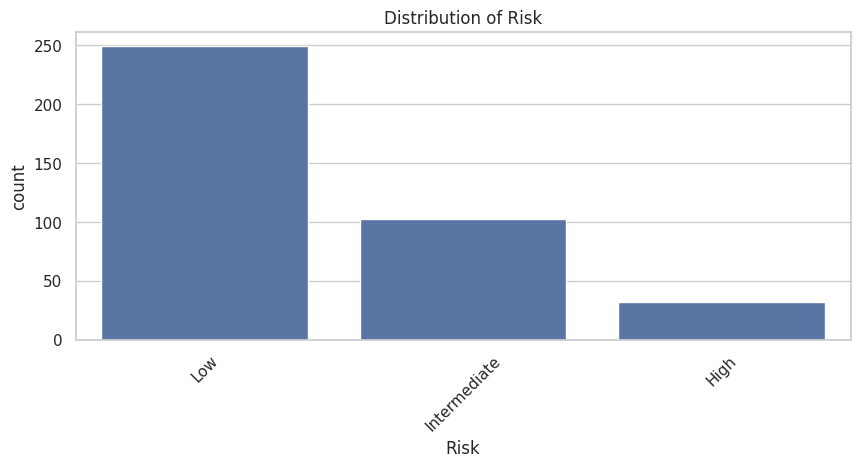

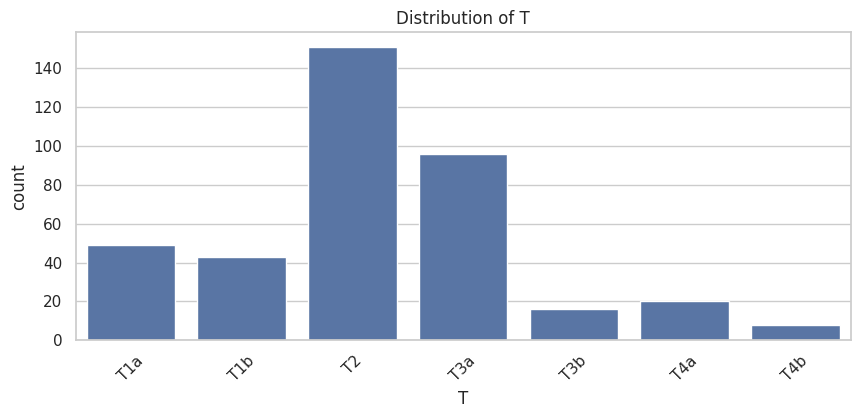

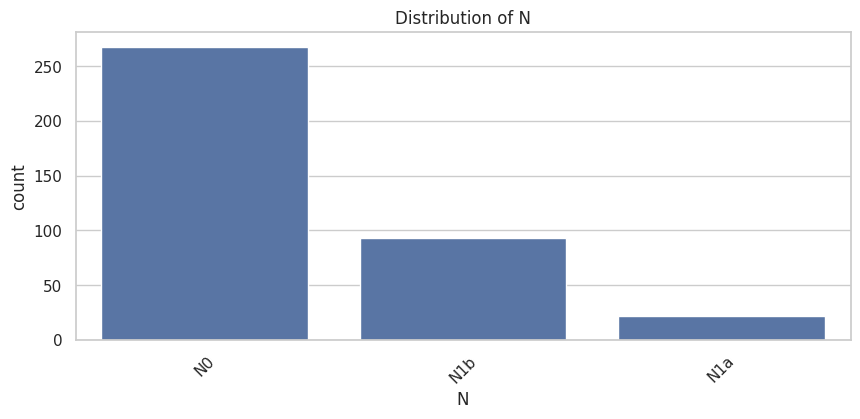

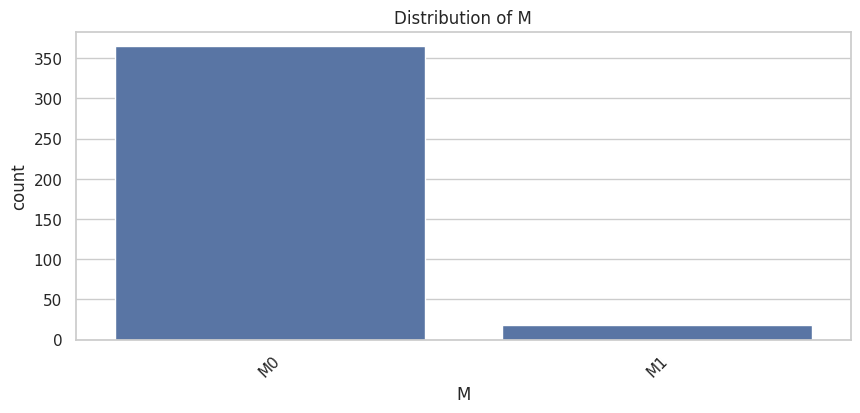

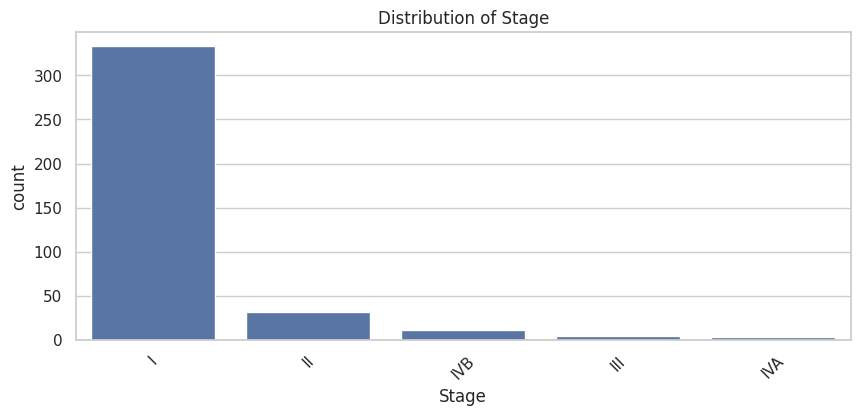

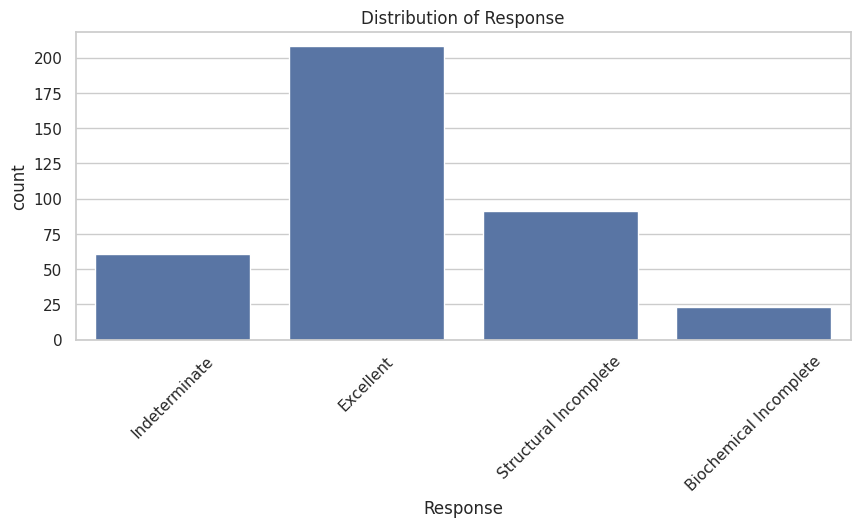

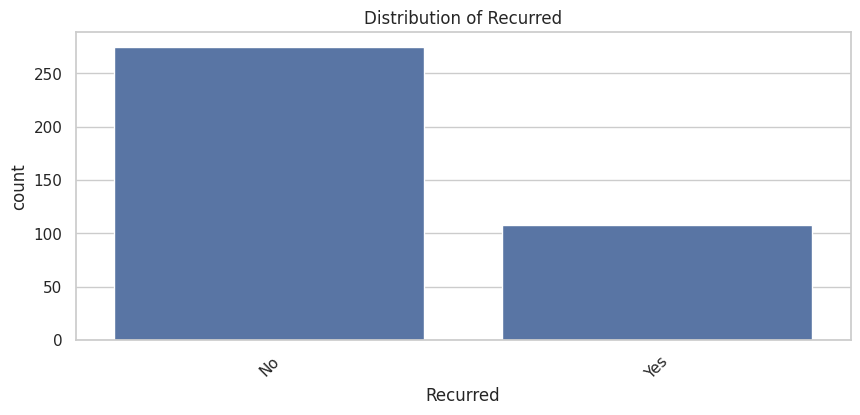

In [ ]:
# Plotting count plots for categorical features
for col in df.select_dtypes(include=['object']).columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

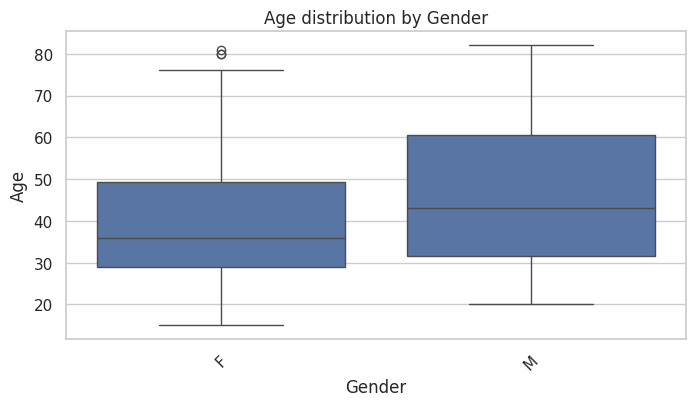

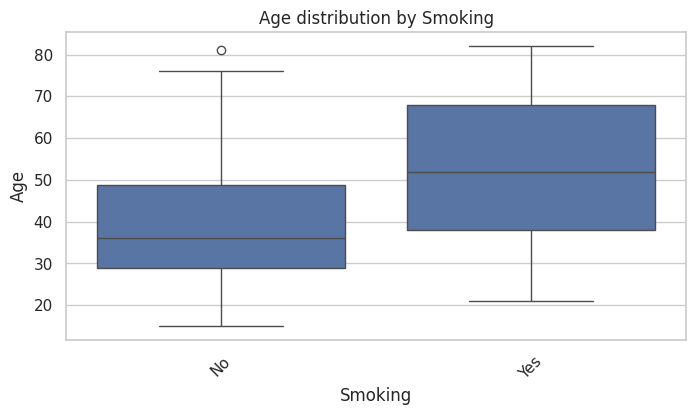

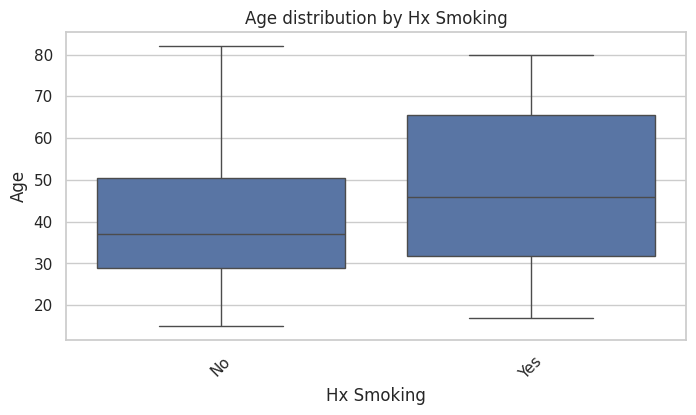

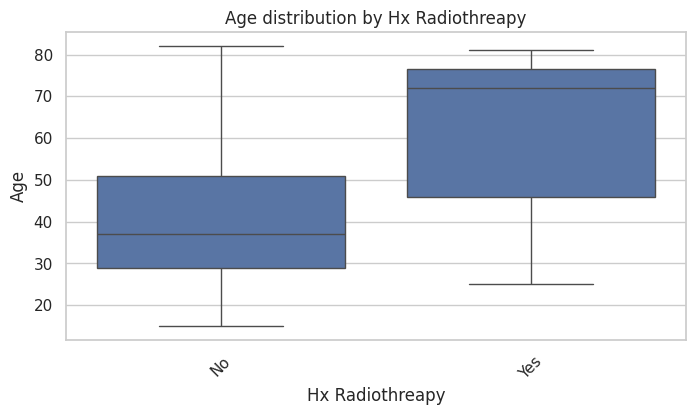

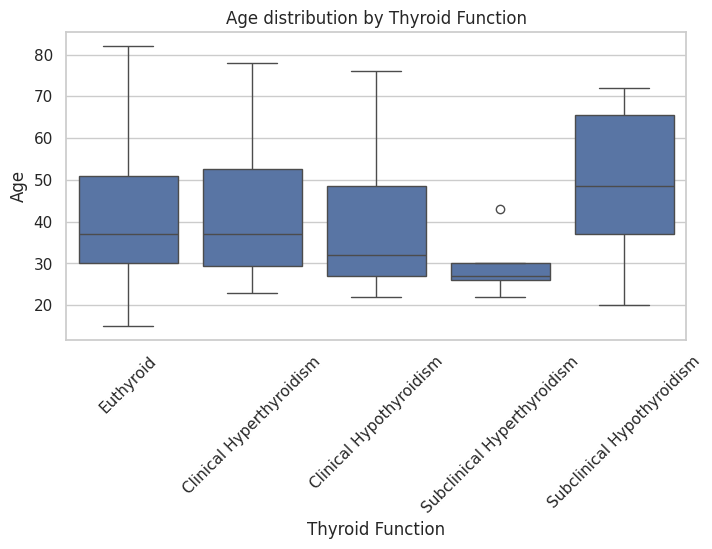

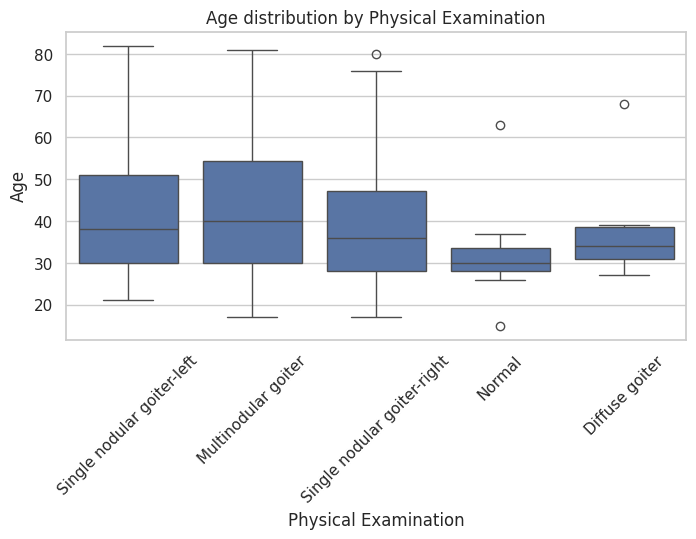

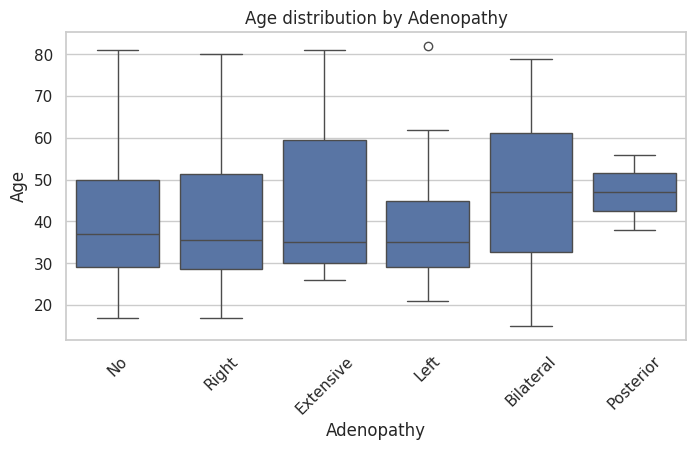

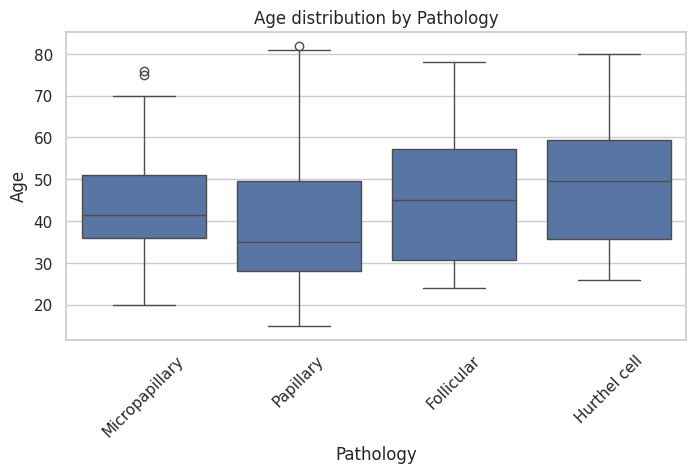

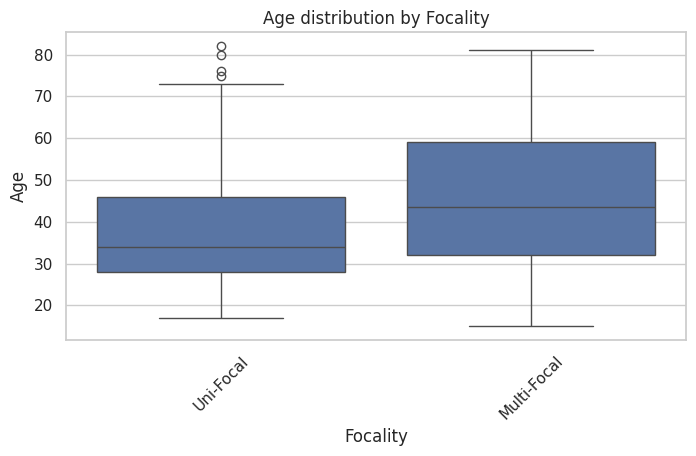

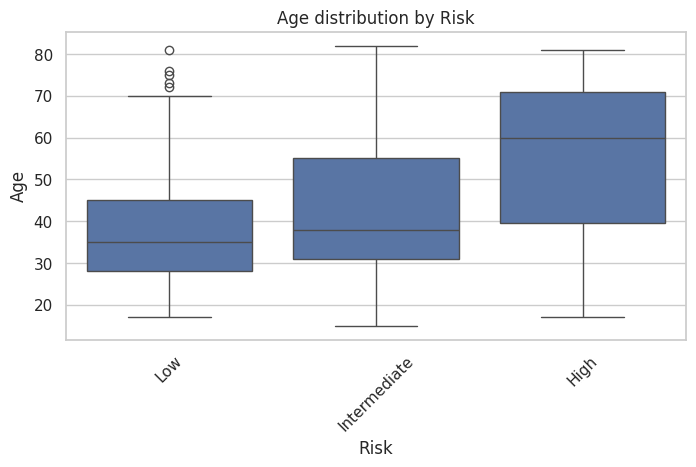

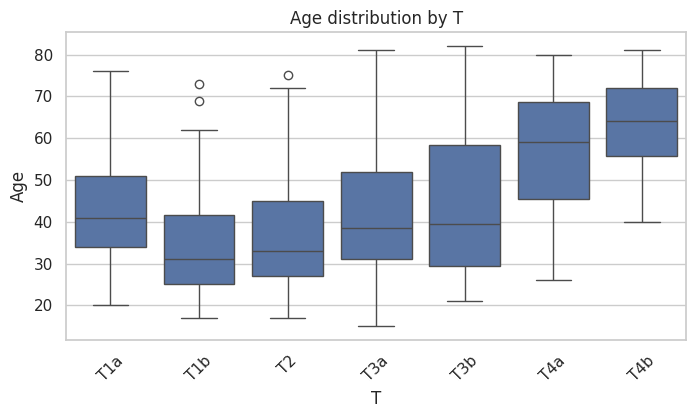

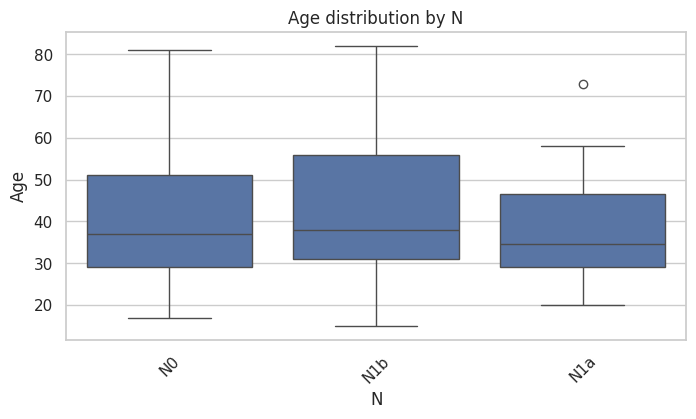

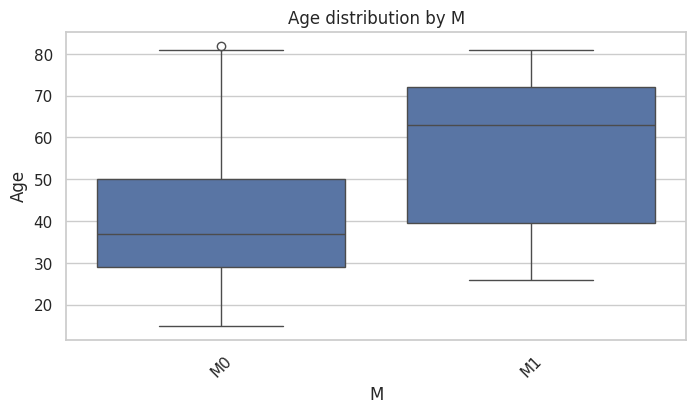

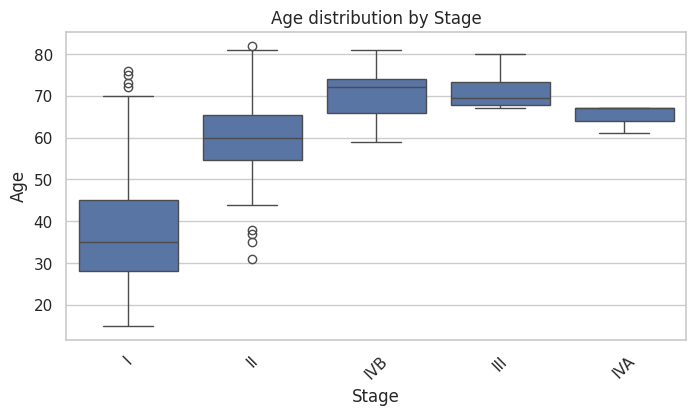

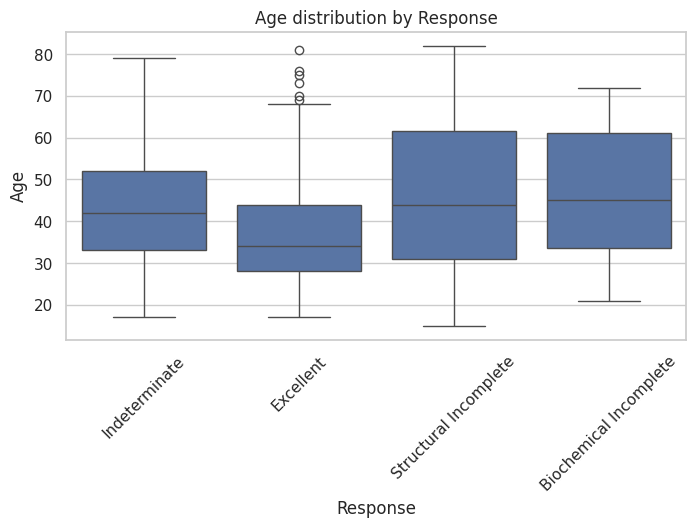

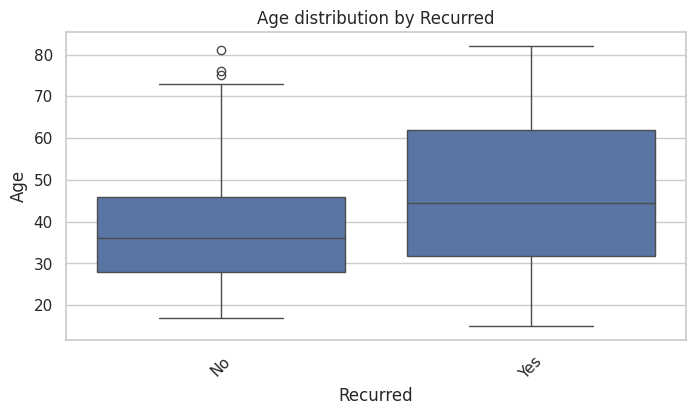

In [ ]:
# Example: Box plot of a numerical variable grouped by a categorical variable
# Replace 'category_column' with the actual column name and 'numerical_column' with the column to analyze
for col in df.select_dtypes(include=['object']).columns:
    for num_col in df.select_dtypes(include=[np.number]).columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=col, y=num_col, data=df)
        plt.title(f'{num_col} distribution by {col}')
        plt.xticks(rotation=45)
        plt.show()

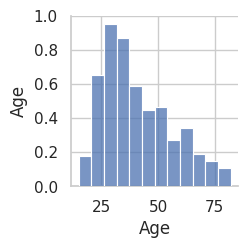

In [ ]:
# Scatter plot between pairs of numerical variables
sns.pairplot(df.select_dtypes(include=[np.number]))
plt.show()

Additional Visualizations for Categorical Variables

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Plotting histograms for each numerical column
numerical_columns = df.select_dtypes(include=[np.number]).columns

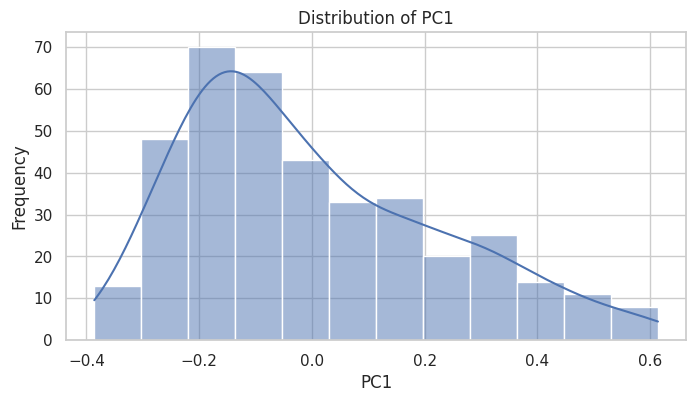

In [ ]:
# Create a histogram for each numerical column
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)  # kde=True adds a kernel density estimate line
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()